In [44]:
import pandas as pd 
import numpy as np 
import datetime as dt 
import matplotlib.pyplot as plt 
import gc 
import sys 
import os 
from datetime import timedelta, datetime 


In [45]:
data = pd.read_csv('../data/raw/SPY_ohlcv_1d.csv')
data['ts_event'] = pd.to_datetime(data['ts_event'])
data.head()

,ts_event,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
0,2020-01-02 00:00:00+00:00,35,43,15144,323.52,325.24,322.535,325.05,11807293,SPY
1,2020-01-03 00:00:00+00:00,35,43,15144,321.82,323.64,319.690,322.67,19279636,SPY
2,2020-01-06 00:00:00+00:00,35,43,15144,320.05,323.95,319.980,323.27,11281994,SPY
3,2020-01-07 00:00:00+00:00,35,43,15144,324.10,324.13,318.720,319.44,9326614,SPY
4,2020-01-08 00:00:00+00:00,35,43,15144,322.08,325.78,322.030,325.20,15896820,SPY


In [46]:
dollar = data.copy()[['ts_event']]
dollar['dollar'] = 1

In [47]:
dollar.head()

,ts_event,dollar
0,2020-01-02 00:00:00+00:00,1
1,2020-01-03 00:00:00+00:00,1
2,2020-01-06 00:00:00+00:00,1
3,2020-01-07 00:00:00+00:00,1
4,2020-01-08 00:00:00+00:00,1


In [61]:
def backtester(data, dollar, delay = timedelta(days = 1)):
    dollar = dollar.copy() 
    data = data.copy()
    dollar['ts_event'] = (dollar['ts_event'] + delay)
    data['ts_event'] = data['ts_event']
    df = pd.merge_asof(left = data, right = dollar, on = 'ts_event', direction = 'backward') # read doc string
    df['target_shrs'] = df['dollar'] / df['close']
    df['curr_shrs'] = df['target_shrs'].shift()
    df['traded_shrs'] = df['curr_shrs'].diff().combine_first(df['curr_shrs'])
    df['TWAP'] = df['open'] / 2 + df['close'] / 2 # high + low + open + close / 4
    df['cash_spend'] = df['traded_shrs'] * df['TWAP']
    df['net_cash'] = df['cash_spend'].cumsum() * (-1)
    # portfolio = cash + asset value 
    df['asset_value'] = df['curr_shrs'] * df['close']
    df['portfolio'] = df['net_cash'] + df['asset_value']
    return df 

df = backtester(data, dollar)
df.head()

,ts_event,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol,dollar,target_shrs,curr_shrs,traded_shrs,TWAP,cash_spend,net_cash,asset_value,portfolio
0,2020-01-02 00:00:00+00:00,35,43,15144,323.52,325.24,322.535,325.05,11807293,SPY,NaN,NaN,NaN,NaN,324.285,NaN,NaN,NaN,NaN
1,2020-01-03 00:00:00+00:00,35,43,15144,321.82,323.64,319.690,322.67,19279636,SPY,1.0,0.003099,NaN,NaN,322.245,NaN,NaN,NaN,NaN
2,2020-01-06 00:00:00+00:00,35,43,15144,320.05,323.95,319.980,323.27,11281994,SPY,1.0,0.003093,0.003099,0.003099,321.660,0.996870,-0.996870,1.001859,0.004990
3,2020-01-07 00:00:00+00:00,35,43,15144,324.10,324.13,318.720,319.44,9326614,SPY,1.0,0.003130,0.003093,-0.000006,321.770,-0.001851,-0.995019,0.988152,-0.006867
4,2020-01-08 00:00:00+00:00,35,43,15144,322.08,325.78,322.030,325.20,15896820,SPY,1.0,0.003075,0.003130,0.000037,323.640,0.012003,-1.007022,1.018032,0.011009


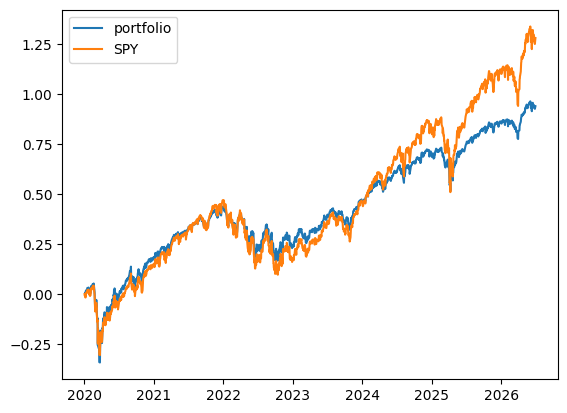

In [63]:
plt.plot(df['ts_event'], df['portfolio'], label = 'portfolio')
plt.plot(data['ts_event'], data['close']/data['close'].iloc[0] - 1, label = 'SPY')
plt.legend()
plt.show()


In [ ]:
# 100 - 10 shares --> 1000 dollar 
# 110 - 10 shares --> 1100 dollar sell 10 shares/sell 100 dollar 